# Blood Pressure

Does blood pressure increase with age?

The `blood-pressure-usa.csv` file contains systolic blood pressure readings from 100 individuals sampled by the National Health and Nutrition Examination Survey (NHANES) in the U.S., with each person measured three times.

The `blood-pressure-yanomami.csv` file features systolic blood pressure data from 71 individuals of the Yanomami Tribe, who live in near-total isolation in the Amazon.

While the average American consumes about 3,500 mg of sodium daily (from salt), the Yanomami's intake is estimated to be less than 100 mg.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'blood-pressure-usa.csv', 'blood-pressure-yanomami.csv', and 'linear_model.py'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('blood-pressure-usa.csv')
df.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [3]:
df_remote = pd.read_csv('blood-pressure-yanomami.csv')
df_remote.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107


### Project Ideas

- Calculate the average blood pressure for each participant in the US dataset.

- Create a linear model for both the US and Yanomami datasets that predicts `bp` from `age`	. 

- Compare the best-fit lines and goodness of fit. What conclusions can you draw?

#### Confounding Variables

The Yanomami people participated in the INTERSALT study, which examined 10,000 individiuals across 52 populations in 32 countries, examining the link between salt consumption and systolic blood pressure. 

Does our data prove that salt intake causes the blood pressure differences between the US and Yanomami populations? What other confounding factors might exist?

In [4]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):

In [5]:
import linear_model

In [7]:
# ── 1. Calculate average BP for each US participant ───────────────────────────
df['bp_avg'] = df[['bp1', 'bp2', 'bp3']].mean(axis=1)
df.head()

,age,bp1,bp2,bp3,bp_avg
0,46,122,129,122,124.333333
1,43,113,116,111,113.333333
2,29,102,107,105,104.666667
3,12,100,102,102,101.333333
4,9,112,138,94,114.666667


In [9]:
# ── 2. Fit linear models for both datasets ────────────────────────────────────
# USA model
model_usa = LinearModel()
model_usa.fit(df['age'], df['bp_avg'])
print("USA Model:")
model_usa.print_model_info()

# Yanomami model
model_yan = LinearModel()
model_yan.fit(df_remote['age'], df_remote['bp'])
print("\nYanomami Model:")
model_yan.print_model_info()

USA Model:
LinearModel():
Slope: 0.7414760958354747
Intercept: 93.36952968206755
R-squared: 0.4720150175059835

Yanomami Model:
LinearModel():
Slope: -0.004198440057105069
Intercept: 95.47465789198789
R-squared: 5.3201360953769594e-05


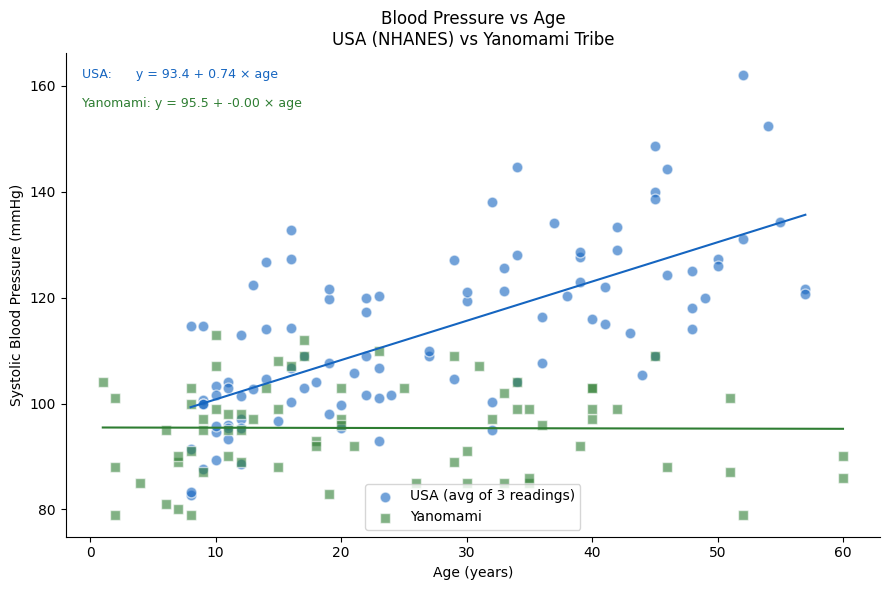

In [10]:
# ── 3. Comparison plot: both datasets + best-fit lines ────────────────────────
plt.figure(figsize=(9, 6))

# Scatter plots
plt.scatter(df['age'], df['bp_avg'],
            color='#1565C0', alpha=0.6, edgecolors='white', s=60,
            label='USA (avg of 3 readings)')
plt.scatter(df_remote['age'], df_remote['bp'],
            color='#2E7D32', alpha=0.6, edgecolors='white', s=60, marker='s',
            label='Yanomami')

# Best-fit lines
model_usa.plot_model(df['age'].min(), df['age'].max(), color='#1565C0')
model_yan.plot_model(df_remote['age'].min(), df_remote['age'].max(), color='#2E7D32')

# Annotate model equations on plot
usa_eq = f"USA:      y = {model_usa.intercept:.1f} + {model_usa.slope:.2f} × age"
yan_eq = f"Yanomami: y = {model_yan.intercept:.1f} + {model_yan.slope:.2f} × age"
plt.text(0.02, 0.97, usa_eq, transform=plt.gca().transAxes,
         fontsize=9, va='top', color='#1565C0')
plt.text(0.02, 0.91, yan_eq, transform=plt.gca().transAxes,
         fontsize=9, va='top', color='#2E7D32')

plt.xlabel('Age (years)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.title('Blood Pressure vs Age\nUSA (NHANES) vs Yanomami Tribe')
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
# ── 4. Summary statistics comparison ──────────────────────────────────────────
print("Summary Comparison")
print("=" * 45)
print(f"{'Metric':<30} {'USA':>7} {'Yanomami':>10}")
print("-" * 45)
print(f"{'Sample size':<30} {len(df):>7} {len(df_remote):>10}")
print(f"{'Mean BP (mmHg)':<30} {df['bp_avg'].mean():>7.1f} {df_remote['bp'].mean():>10.1f}")
print(f"{'Min BP':<30} {df['bp_avg'].min():>7.1f} {df_remote['bp'].min():>10.1f}")
print(f"{'Max BP':<30} {df['bp_avg'].max():>7.1f} {df_remote['bp'].max():>10.1f}")
print(f"{'Slope (BP rise per year)':<30} {model_usa.slope:>7.3f} {model_yan.slope:>10.3f}")

Summary Comparison
Metric                             USA   Yanomami
---------------------------------------------
Sample size                        100         71
Mean BP (mmHg)                   113.3       95.4
Min BP                            82.7       79.0
Max BP                           162.0      113.0
Slope (BP rise per year)         0.741     -0.004
